- model comparison between the sigmoid and linear fits for mean subject-level playfight curves

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
path_to_add = os.path.abspath('../')
sys.path.append(path_to_add)
from func_fix_curvefit_params import *

In [7]:
root_folder = '../../data/playfight_data/'

In [8]:
df_linear = pd.read_csv(f'{root_folder}/curve_fit_pf_ses2_linear/all_params_1k_play_linear.csv')#merged_apr_ses1.csv')#('../data/ses1_data/curve_fit_rmse/all_params_1k.csv')
bad_rows = (np.isnan(df_linear['obj_center'])) | \
      (np.isinf(df_linear['obj_center'])) | \
    (df_linear['obj_center']<0)
df_linear.loc[bad_rows,:]

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
5,26007.0,0.583599,0.255097,-24.829610,-0.019885,0.453000,0.509008,0.509008,0.037992,0.0,0.0,False
6,26008.0,0.803762,0.155699,-42.858682,-0.854731,0.213643,0.682607,0.682607,0.103750,0.0,0.0,False
24,26037.0,0.001659,0.307259,-34.303468,-9.950441,0.007929,0.578893,0.578893,0.413179,0.0,0.0,False
41,26060.0,0.823969,0.151992,-38.196440,-0.087761,0.318643,0.527964,0.527964,0.153393,0.0,0.0,False
63,26089.0,0.750620,0.178842,-34.875283,-0.010548,0.323929,0.503417,0.503417,0.172655,0.0,0.0,False
70,26096.0,0.203453,0.317590,-29.517473,-0.284030,0.138357,0.539298,0.539298,0.322345,0.0,0.0,False
73,26099.0,0.470037,0.262099,-50.282789,-0.010378,0.058500,0.500607,0.500607,0.440893,0.0,0.0,False
120,26161.0,0.867970,0.117954,-43.276108,-0.474986,0.262714,0.624786,0.624786,0.112500,0.0,0.0,False
122,26163.0,0.348776,0.258420,-41.318617,-1.340051,0.086238,0.615563,0.615563,0.298198,0.0,0.0,False
124,26167.0,0.860705,0.129607,-47.709068,-0.043495,0.185571,0.508071,0.508071,0.306357,0.0,0.0,False


In [9]:
df_linear = fix_obj_center(df_linear)
bad_rows = (np.isnan(df_linear['obj_center'])) | \
      (np.isinf(df_linear['obj_center'])) | \
    (df_linear['obj_center']<0)
df_linear.loc[bad_rows,:]

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
46,26067.0,0.284428,0.290743,-54.685573,NaN,0.028595,NaN,0.534440,0.494155,1.0,1.0,True
126,26169.0,0.397730,0.258664,-34.969223,NaN,0.150714,NaN,0.580119,0.570595,1.0,1.0,True
136,26182.0,0.000000,0.305028,-26.694628,NaN,0.000000,NaN,0.499143,0.500857,1.0,1.0,True
145,26193.0,0.856144,0.133840,-27.144130,NaN,0.791238,NaN,0.913524,0.877714,1.0,1.0,True
199,26263.0,0.854329,0.118509,-37.162888,NaN,0.384000,NaN,0.791286,0.592714,1.0,1.0,True


In [10]:
df_sigmoid = pd.read_csv(f'{root_folder}/curve_fit_aggressiveness_ses2_sigmoid/all_params_1k_fight.csv')#('../data/ses1_data/curve_fit_rmse/all_params_1k.csv')
# df_sigmoid = pd.read_csv(f'{root_folder}/curve_fit_pf_ses1/all_params_1k_play.csv')#('../data/ses1_data/curve_fit_rmse/all_params_1k.csv')
bad_rows = (np.isnan(df_sigmoid['obj_center'])) | \
      (np.isinf(df_sigmoid['obj_center'])) | \
    (df_sigmoid['obj_center']<0)
df_sigmoid.loc[bad_rows,:]

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
6,26008.0,0.848791,0.142192,-23.308100,0.399625,NaN,0.159978,0.105176,0.691178,0.088,0.686000,False
41,26060.0,0.940510,0.102650,-27.870025,0.313352,NaN,0.105285,0.132669,0.560474,0.117,0.560000,False
46,26067.0,0.291360,0.289435,-13.357542,0.734166,-0.200341,0.387198,0.494590,0.533211,0.512,0.540000,True
120,26161.0,0.835312,0.132602,-24.285658,0.512082,NaN,0.235046,0.135443,0.636720,0.106,0.604444,False
122,26163.0,0.383573,0.251468,-15.326128,0.200257,NaN,0.285625,0.287398,0.619713,0.237,0.611000,False
175,26233.0,0.213007,0.316588,-12.102136,0.231679,NaN,0.466775,0.351059,0.556491,0.275,0.524000,False
194,26258.0,0.749801,0.208071,-17.978266,0.307324,NaN,0.072722,0.210938,0.588015,0.208,0.588000,False
197,26261.0,0.927765,0.091574,-29.468543,0.548795,NaN,0.198765,0.050296,0.560978,0.023,0.518000,False
209,26274.0,0.922593,0.106297,-27.381202,0.668086,NaN,0.135847,0.011672,0.652414,0.009,0.623000,False
210,26275.0,0.977518,0.056794,-36.156556,0.567700,NaN,0.136060,0.263507,0.518247,0.260,0.509000,False


In [11]:
df_sigmoid = fix_obj_center(df_sigmoid)
bad_rows = (np.isnan(df_sigmoid['obj_center'])) | \
      (np.isinf(df_sigmoid['obj_center'])) | \
    (df_sigmoid['obj_center']<0)
df_sigmoid.loc[bad_rows,:]

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
46,26067.0,0.291360,0.289435,-13.357542,0.734166,NaN,0.387198,0.494590,0.533211,0.512000,0.540,True
126,26169.0,0.374354,0.264127,-14.638553,0.364812,NaN,0.377425,0.555547,0.580141,0.593000,0.646,True
136,26182.0,-0.286111,0.346663,-10.831643,1.129821,NaN,1.000000,0.535138,0.546625,0.730000,0.636,True
145,26193.0,0.893658,0.117572,-25.969851,0.563736,NaN,0.172479,0.848144,0.870379,0.907778,0.900,True
199,26263.0,0.816163,0.133456,-24.195794,0.559390,NaN,0.258240,0.569469,0.762138,0.638000,0.808,True


In [12]:
df_linear = add_new_params(df_linear)
df_linear.loc[df_linear['range']<0,:]

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
46,26067.0,0.284428,0.290743,-54.685573,NaN,0.028595,NaN,0.534440,0.494155,1.0,1.0,True,-0.028595,0.519583
126,26169.0,0.397730,0.258664,-34.969223,NaN,0.150714,NaN,0.580119,0.570595,1.0,1.0,True,-0.150714,0.504138
145,26193.0,0.856144,0.133840,-27.144130,NaN,0.791238,NaN,0.913524,0.877714,1.0,1.0,True,-0.791238,0.509996
199,26263.0,0.854329,0.118509,-37.162888,NaN,0.384000,NaN,0.791286,0.592714,1.0,1.0,True,-0.384000,0.571738


In [13]:
df_linear = df_linear.loc[df_linear['range']>0,:] # remove negative amplitudes
df_linear.loc[df_linear['range']<0,:]

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [14]:
bad_rows = (np.isnan(df_linear['obj_center'])) | \
      (np.isinf(df_linear['obj_center'])) | \
    (df_linear['obj_center']<0)
df_linear.loc[bad_rows,:]

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [15]:
df_sigmoid = add_new_params(df_sigmoid)
df_sigmoid.loc[df_sigmoid['range']<0,:]

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
46,26067.0,0.291360,0.289435,-13.357542,0.734166,NaN,0.387198,0.494590,0.533211,0.512000,0.540,True,-0.027802,0.481212
126,26169.0,0.374354,0.264127,-14.638553,0.364812,NaN,0.377425,0.555547,0.580141,0.593000,0.646,True,-0.135688,0.489173
136,26182.0,-0.286111,0.346663,-10.831643,1.129821,NaN,1.000000,0.535138,0.546625,0.730000,0.636,True,-0.081763,0.494691
145,26193.0,0.893658,0.117572,-25.969851,0.563736,NaN,0.172479,0.848144,0.870379,0.907778,0.900,True,-0.718523,0.493531
199,26263.0,0.816163,0.133456,-24.195794,0.559390,NaN,0.258240,0.569469,0.762138,0.638000,0.808,True,-0.331607,0.427656


In [16]:
df_sigmoid = df_sigmoid.loc[df_sigmoid['range']>0,:] # remove negative amplitudes
df_sigmoid.loc[df_sigmoid['range']<0,:]

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [17]:
bad_rows = (np.isnan(df_sigmoid['obj_center'])) | \
      (np.isinf(df_sigmoid['obj_center'])) | \
    (df_sigmoid['obj_center']<0)
df_sigmoid.loc[bad_rows,:]

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [18]:
df_linear.rename({'obj_center':'PSE'},inplace=True)
df_linear.drop(columns=['bias_lower', 'bias_upper'],inplace=True)
df_linear.head()

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,flipped,range,bias
0,26000.0,0.924233,0.114475,-39.241819,0.124705,0.477381,0.440468,0.440468,0.082151,False,0.477381,0.842809
1,26001.0,0.810345,0.140828,-30.664804,0.495616,0.521357,0.241607,0.241607,0.237036,False,0.521357,0.504775
2,26003.0,0.948120,0.087003,-31.126282,0.507930,0.984191,0.000100,0.000100,0.015709,False,0.984191,0.006326
3,26004.0,0.850246,0.130596,-45.074530,0.202595,0.214714,0.456500,0.456500,0.328786,False,0.214714,0.581317
4,26005.0,0.978372,0.053982,-40.003157,0.369992,0.870643,0.177869,0.177869,0.000000,False,0.822131,1.000000


In [19]:
df_sigmoid.rename({'obj_center':'PSE'},inplace=True)
df_sigmoid.drop(columns=['bias_lower', 'bias_upper'],inplace=True)
df_sigmoid

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,flipped,range,bias
0,26000.0,0.984906,0.053026,-37.117490,0.510340,0.759109,0.097806,0.133145,0.473647,False,0.393208,0.219425
1,26001.0,0.916683,0.100385,-28.182328,0.334429,0.401482,0.165944,0.212210,0.271624,False,0.516166,0.438600
2,26003.0,0.978942,0.056049,-36.341300,0.422956,0.440821,0.136716,0.042550,0.076534,False,0.880916,0.357309
3,26004.0,0.835341,0.137325,-23.795706,0.382026,0.755733,0.209161,0.334892,0.478390,False,0.186718,0.411778
4,26005.0,0.989901,0.036901,-42.193119,0.546047,0.609801,0.150020,0.037118,0.220983,False,0.741899,0.143811
...,...,...,...,...,...,...,...,...,...,...,...,...
264,26343.0,0.900031,0.098742,-28.413457,0.408635,0.530859,0.232758,0.140210,0.276645,False,0.583145,0.336352
265,26344.0,0.952487,0.082713,-30.893248,0.596879,0.647165,0.147609,0.036095,0.210036,False,0.753869,0.146650
266,26346.0,0.960917,0.067822,-33.672083,0.358269,0.394177,0.172504,0.262137,0.270776,False,0.467087,0.491895
267,26347.0,0.924006,0.092597,-29.312945,0.446505,0.662079,0.196224,0.308207,0.443415,False,0.248379,0.410056


In [20]:
rows = (np.isnan(df_linear['aic'])) | (np.isinf(df_linear['aic']))
df_linear.loc[rows,:]

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,flipped,range,bias


In [21]:
rows = (np.isnan(df_sigmoid['aic'])) | (np.isinf(df_sigmoid['aic']))
df_sigmoid.loc[rows,:] # looks like a reasonable sub, but have to discard bc we need AIC

,subID,r_squared,nrmse,aic,center,obj_center,sigma,bias_xmin,bias_xmax,flipped,range,bias


In [22]:
rows = ~(np.isnan(df_linear['aic'])) & ~(np.isinf(df_linear['aic']))
print('size, before:', df_linear.shape)
df_linear = df_linear.loc[rows,:]
print('size, after:', df_linear.shape)

size, before: (264, 12)
size, after: (264, 12)


In [23]:
rows = ~(np.isnan(df_sigmoid['aic'])) & ~(np.isinf(df_sigmoid['aic']))
print('size, before:', df_sigmoid.shape)
df_sigmoid = df_sigmoid.loc[rows,:]
print('size, after:', df_sigmoid.shape)

size, before: (264, 12)
size, after: (264, 12)


In [24]:
np.where(np.isnan(df_sigmoid))

(array([], dtype=int64), array([], dtype=int64))

In [25]:
cols = list(df_linear.columns)
cols_new = [i + '_linear' for i in cols]
df_linear.rename(columns = dict(zip(cols, cols_new)),inplace=True)
df_linear

,subID_linear,r_squared_linear,nrmse_linear,aic_linear,obj_center_linear,slope_linear,intercept_linear,bias_xmin_linear,bias_xmax_linear,flipped_linear,range_linear,bias_linear
0,26000.0,0.924233,0.114475,-39.241819,0.124705,0.477381,0.440468,0.440468,0.082151,False,0.477381,0.842809
1,26001.0,0.810345,0.140828,-30.664804,0.495616,0.521357,0.241607,0.241607,0.237036,False,0.521357,0.504775
2,26003.0,0.948120,0.087003,-31.126282,0.507930,0.984191,0.000100,0.000100,0.015709,False,0.984191,0.006326
3,26004.0,0.850246,0.130596,-45.074530,0.202595,0.214714,0.456500,0.456500,0.328786,False,0.214714,0.581317
4,26005.0,0.978372,0.053982,-40.003157,0.369992,0.870643,0.177869,0.177869,0.000000,False,0.822131,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
264,26343.0,0.932664,0.080978,-35.254970,0.427334,0.676286,0.211000,0.211000,0.112714,False,0.676286,0.651809
265,26344.0,0.936623,0.094923,-31.778106,0.358499,0.895500,0.178964,0.178964,0.000000,False,0.821036,1.000000
266,26346.0,0.937625,0.083382,-39.407191,0.546918,0.523714,0.213571,0.213571,0.262714,False,0.523714,0.448410
267,26347.0,0.934168,0.085602,-47.646641,0.273320,0.282476,0.422794,0.422794,0.294730,False,0.282476,0.589240


In [26]:
cols = list(df_sigmoid.columns)
cols_new = [i + '_sigmoid' for i in cols]
df_sigmoid.rename(columns = dict(zip(cols, cols_new)),inplace=True)
df_sigmoid

,subID_sigmoid,r_squared_sigmoid,nrmse_sigmoid,aic_sigmoid,center_sigmoid,obj_center_sigmoid,sigma_sigmoid,bias_xmin_sigmoid,bias_xmax_sigmoid,flipped_sigmoid,range_sigmoid,bias_sigmoid
0,26000.0,0.984906,0.053026,-37.117490,0.510340,0.759109,0.097806,0.133145,0.473647,False,0.393208,0.219425
1,26001.0,0.916683,0.100385,-28.182328,0.334429,0.401482,0.165944,0.212210,0.271624,False,0.516166,0.438600
2,26003.0,0.978942,0.056049,-36.341300,0.422956,0.440821,0.136716,0.042550,0.076534,False,0.880916,0.357309
3,26004.0,0.835341,0.137325,-23.795706,0.382026,0.755733,0.209161,0.334892,0.478390,False,0.186718,0.411778
4,26005.0,0.989901,0.036901,-42.193119,0.546047,0.609801,0.150020,0.037118,0.220983,False,0.741899,0.143811
...,...,...,...,...,...,...,...,...,...,...,...,...
264,26343.0,0.900031,0.098742,-28.413457,0.408635,0.530859,0.232758,0.140210,0.276645,False,0.583145,0.336352
265,26344.0,0.952487,0.082713,-30.893248,0.596879,0.647165,0.147609,0.036095,0.210036,False,0.753869,0.146650
266,26346.0,0.960917,0.067822,-33.672083,0.358269,0.394177,0.172504,0.262137,0.270776,False,0.467087,0.491895
267,26347.0,0.924006,0.092597,-29.312945,0.446505,0.662079,0.196224,0.308207,0.443415,False,0.248379,0.410056


In [27]:
df_both =  df_linear.merge(df_sigmoid, left_on = 'subID_linear', right_on = 'subID_sigmoid')
#pd.concat([df_linear.set_index('subID_linear'),df_sigmoid.set_index('subID_sigmoid')]),axis=1)
print(df_both.shape)

(264, 24)


In [28]:
print(df_both.shape)
rows = (df_both['range_sigmoid']>0) & (df_both['slope_linear']>0)
df_both.loc[rows,:].shape

(264, 24)


(264, 24)

In [29]:
df_both.rename(columns={'obj_center_linear':'PSE_linear','obj_center_sigmoid':'PSE_sigmoid'},inplace=True)
df_both

,subID_linear,r_squared_linear,nrmse_linear,aic_linear,PSE_linear,slope_linear,intercept_linear,bias_xmin_linear,bias_xmax_linear,flipped_linear,...,nrmse_sigmoid,aic_sigmoid,center_sigmoid,PSE_sigmoid,sigma_sigmoid,bias_xmin_sigmoid,bias_xmax_sigmoid,flipped_sigmoid,range_sigmoid,bias_sigmoid
0,26000.0,0.924233,0.114475,-39.241819,0.124705,0.477381,0.440468,0.440468,0.082151,False,...,0.053026,-37.117490,0.510340,0.759109,0.097806,0.133145,0.473647,False,0.393208,0.219425
1,26001.0,0.810345,0.140828,-30.664804,0.495616,0.521357,0.241607,0.241607,0.237036,False,...,0.100385,-28.182328,0.334429,0.401482,0.165944,0.212210,0.271624,False,0.516166,0.438600
2,26003.0,0.948120,0.087003,-31.126282,0.507930,0.984191,0.000100,0.000100,0.015709,False,...,0.056049,-36.341300,0.422956,0.440821,0.136716,0.042550,0.076534,False,0.880916,0.357309
3,26004.0,0.850246,0.130596,-45.074530,0.202595,0.214714,0.456500,0.456500,0.328786,False,...,0.137325,-23.795706,0.382026,0.755733,0.209161,0.334892,0.478390,False,0.186718,0.411778
4,26005.0,0.978372,0.053982,-40.003157,0.369992,0.870643,0.177869,0.177869,0.000000,False,...,0.036901,-42.193119,0.546047,0.609801,0.150020,0.037118,0.220983,False,0.741899,0.143811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,26343.0,0.932664,0.080978,-35.254970,0.427334,0.676286,0.211000,0.211000,0.112714,False,...,0.098742,-28.413457,0.408635,0.530859,0.232758,0.140210,0.276645,False,0.583145,0.336352
260,26344.0,0.936623,0.094923,-31.778106,0.358499,0.895500,0.178964,0.178964,0.000000,False,...,0.082713,-30.893248,0.596879,0.647165,0.147609,0.036095,0.210036,False,0.753869,0.146650
261,26346.0,0.937625,0.083382,-39.407191,0.546918,0.523714,0.213571,0.213571,0.262714,False,...,0.067822,-33.672083,0.358269,0.394177,0.172504,0.262137,0.270776,False,0.467087,0.491895
262,26347.0,0.934168,0.085602,-47.646641,0.273320,0.282476,0.422794,0.422794,0.294730,False,...,0.092597,-29.312945,0.446505,0.662079,0.196224,0.308207,0.443415,False,0.248379,0.410056


In [30]:
# rows = (df_both['amplitude_sigmoid']>0) & (df_both['slope_linear']>0)
# df_both = df_both.loc[rows,:]
# print(df_both.shape)
# df_both.head()

# sanity checks

In [31]:
def get_p(p):
    if p < .001:
        return "p < .001"
    elif p < .01:
        return f"p={p:.3f}"
    else:
        return f"p={p:.2f}"
        
def explore_correlations(df, param, ax):

    from scipy.stats import pearsonr,spearmanr

    if param == 'slope':
        x = df[param+'_linear']
        y = df['sigma_sigmoid']
    else:
        x = df[param+'_linear']
        y = df[param+'_sigmoid']
    
    rows = (~np.isnan(x)) & (~np.isnan(y)) & (~np.isinf(x)) & (~np.isinf(y))
    x = x[rows]
    y = y[rows]

    sns.scatterplot(x=x, y=y,color='k',alpha=.3,ax=ax)
    r,p = pearsonr(x,y)
    if p < .05:
        color = 'k'
        fontweight = 'bold'
    else:
        color = 'k'
        fontweight = 'normal'
    ax.annotate(f'r_p={r:.2f} ({get_p(p)})',xy=(0.05,.9),xycoords='axes fraction', color = color, fontweight = fontweight, ha='left',va='top')


    r,p = spearmanr(x,y)
    if p < .05:
        color = 'k'
        fontweight = 'bold'
    else:
        color = 'k'
        fontweight = 'normal'
    ax.annotate(f'r_s={r:.2f} ({get_p(p)})',xy=(0.05,.8),xycoords='axes fraction', color = color, fontweight = fontweight, ha='left',va='top')


In [32]:
comparisons = ['bias_xmin','bias_xmax','bias','PSE','range','slope','r_squared']

In [33]:
df_both

,subID_linear,r_squared_linear,nrmse_linear,aic_linear,PSE_linear,slope_linear,intercept_linear,bias_xmin_linear,bias_xmax_linear,flipped_linear,...,nrmse_sigmoid,aic_sigmoid,center_sigmoid,PSE_sigmoid,sigma_sigmoid,bias_xmin_sigmoid,bias_xmax_sigmoid,flipped_sigmoid,range_sigmoid,bias_sigmoid
0,26000.0,0.924233,0.114475,-39.241819,0.124705,0.477381,0.440468,0.440468,0.082151,False,...,0.053026,-37.117490,0.510340,0.759109,0.097806,0.133145,0.473647,False,0.393208,0.219425
1,26001.0,0.810345,0.140828,-30.664804,0.495616,0.521357,0.241607,0.241607,0.237036,False,...,0.100385,-28.182328,0.334429,0.401482,0.165944,0.212210,0.271624,False,0.516166,0.438600
2,26003.0,0.948120,0.087003,-31.126282,0.507930,0.984191,0.000100,0.000100,0.015709,False,...,0.056049,-36.341300,0.422956,0.440821,0.136716,0.042550,0.076534,False,0.880916,0.357309
3,26004.0,0.850246,0.130596,-45.074530,0.202595,0.214714,0.456500,0.456500,0.328786,False,...,0.137325,-23.795706,0.382026,0.755733,0.209161,0.334892,0.478390,False,0.186718,0.411778
4,26005.0,0.978372,0.053982,-40.003157,0.369992,0.870643,0.177869,0.177869,0.000000,False,...,0.036901,-42.193119,0.546047,0.609801,0.150020,0.037118,0.220983,False,0.741899,0.143811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,26343.0,0.932664,0.080978,-35.254970,0.427334,0.676286,0.211000,0.211000,0.112714,False,...,0.098742,-28.413457,0.408635,0.530859,0.232758,0.140210,0.276645,False,0.583145,0.336352
260,26344.0,0.936623,0.094923,-31.778106,0.358499,0.895500,0.178964,0.178964,0.000000,False,...,0.082713,-30.893248,0.596879,0.647165,0.147609,0.036095,0.210036,False,0.753869,0.146650
261,26346.0,0.937625,0.083382,-39.407191,0.546918,0.523714,0.213571,0.213571,0.262714,False,...,0.067822,-33.672083,0.358269,0.394177,0.172504,0.262137,0.270776,False,0.467087,0.491895
262,26347.0,0.934168,0.085602,-47.646641,0.273320,0.282476,0.422794,0.422794,0.294730,False,...,0.092597,-29.312945,0.446505,0.662079,0.196224,0.308207,0.443415,False,0.248379,0.410056


In [34]:
# nrows = 3
# ncols = 3
# fig,axs = plt.subplots(nrows = nrows, ncols = ncols, figsize = (10,10))
# for i,param in enumerate(comparisons):
#     r = int(np.floor(i/ncols))
#     c = i%ncols
#     ax = axs[r,c]
#     explore_correlations(df_both, param, ax)
#     ax.set_title(param,fontweight='bold')
#     if param == 'slope':
#         ax.set_title ('slope vs. inv. sigma',fontweight='bold')

# df_melted = df_both.melt(value_vars=['aic_linear', 'aic_sigmoid'], var_name='Model', value_name='AIC')
# df_melted = df_melted.reset_index().rename(columns={'index': 'Row'})

# ax = axs[2,1]
# sns.boxplot(x='Model', y='AIC', data=df_melted,ax=ax, color = 'w')
# ax.set_xlabel('')
# for i in df_both.index:
#     ax.plot(['aic_linear', 'aic_sigmoid'], [df_both.loc[i, 'aic_linear'], df_both.loc[i, 'aic_sigmoid']], marker='o', color='k',alpha = .05)
# ax.set_title('AIC',fontweight='bold')
# ax.set_ylim(-100,0)

# ax = axs[2,2]
# ax.axis('off')

# plt.suptitle('Linear (X) vs. sigmoid(Y) fits (pf sess1)', fontweight='bold', fontsize=16)
# plt.tight_layout()
# # plt.savefig('../../results/playfight/linear_vs_sigmoid_ses2.png',dpi=300,bbox_inches='tight')

In [35]:
df_both.to_csv('../../data/playfight_data/curvefits_linear_sigmoid_params_ses2.csv')

In [36]:
from scipy import stats

In [37]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [38]:
t,p =  stats.ttest_rel(df_both['aic_sigmoid'],df_both['aic_linear'])
t,p

(13.655123398365632, 1.8850481802113485e-32)

In [42]:
(df_both['aic_sigmoid']-df_both['aic_linear']).mean()

7.3003648796883605

In [39]:
df_both['aic_sigmoid'].mean(),df_both['aic_linear'].mean(), df_both['aic_sigmoid'].std(),df_both['aic_linear'].std()

(-30.261850580138145,
 -37.562215459826476,
 6.5835504866285115,
 7.0840592731116665)

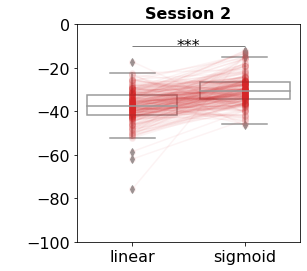

In [41]:
df_melted = df_both.melt(value_vars=['aic_linear', 'aic_sigmoid'], var_name='Model', value_name='AIC')
df_melted = df_melted.reset_index().rename(columns={'index': 'Row'})

fig,ax = plt.subplots(figsize=(4,4),nrows=1,ncols=1)
sns.boxplot(x='Model', y='AIC', data=df_melted,ax=ax, color = 'w')
ax.set_xlabel('')
for i in df_both.index:
    ax.plot(['aic_linear', 'aic_sigmoid'], [df_both.loc[i, 'aic_linear'], df_both.loc[i, 'aic_sigmoid']], marker='o', color='tab:red',alpha = .05)
if p < .05:
    ax.hlines(-10,0,1,color = 'k',linewidth=.5)
    if p<.001:
        txt = '***'
    elif p < .01:
        txt = '**'
    else:
        txt = '*'
    ax.text(0.5,-12,txt,color = 'k',ha='center')
ax.set_title('Session 2',fontweight='bold')
ax.set_ylim(-100,0)
ax.set_xticklabels(['linear','sigmoid'])
ax.set_ylabel('   ')
plt.savefig('../../results/playfight/AIC_linear_vs_sigmoid_ses2.png',bbox_inches='tight',dpi=300)

Ttest_relResult(statistic=13.248928287417588, pvalue=1.042572241830733e-30)

(-29.227208785525068, -37.62291301856578, 6.457097179985464, 7.062631157514021)

In [36]:
df_both['aic_diff'] = df_both['aic_sigmoid'] - df_both['aic_linear']
# len(np.where(df_both['aic_diff']>0)[0]), len(np.where(df_both['aic_diff']==0)[0]), len(np.where(df_both['aic_diff']<0)[0])
len(np.where(df_both['aic_diff']>5)[0]), len(np.where(df_both['aic_diff']==0)[0]), len(np.where(df_both['aic_diff']<-5)[0])

(165, 0, 17)

In [37]:
len(np.where(df_both['aic_diff']>10)[0]), len(np.where(df_both['aic_diff']==0)[0]), len(np.where(df_both['aic_diff']<-10)[0])

(99, 0, 6)